# Simulations

In [1]:
import os
import sys

sys.path.insert(0, '/banach2/wes/locat-0.1')
sys.path.insert(0, '/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations')

# If the old locat package was already imported in this kernel, clear it so imports below use locat-0.1.
for mod in list(sys.modules):
    if mod == 'locat' or mod.startswith('locat.'):
        del sys.modules[mod]


In [2]:
import os

In [3]:
!nvidia-smi

Tue Mar 17 11:36:58 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A6000    Off  | 00000000:01:00.0 Off |                  Off |
| 32%   60C    P2   104W / 300W |   2580MiB / 49140MiB |     14%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A6000    Off  | 00000000:24:00.0 Off |                  Off |
| 30%   

In [4]:
from numpy import random
import numpy as np

In [5]:
os.environ['CUDA_VISIBLE_DEVICES'] = '4'
SEED = 13
os.environ["PYTHONHASHSEED"] = str(SEED)

def reset_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    return seed

reset_seeds(SEED)


13

In [6]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.datasets import make_blobs

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
from sklearn.metrics import roc_curve

In [8]:
from locat.locat import LOCAT


In [9]:
adata_dir = "/banach2/wes/Locat/data/E145_dermal_erez_2026/"

In [10]:
adata = sc.read_h5ad(adata_dir+'dc_adata_proc.h5ad')

In [11]:
adata.obsm

AxisArrays with keys: X_pca, X_pca_partition1, X_pca_partition2, X_tsne, X_umap, X_umap_partition1, X_umap_partition2

In [12]:
import numpy as np
import scanpy as sc
import scipy.sparse as sp

# ----------------------------
# Load data
# ----------------------------
adata_dir = "/banach2/wes/Locat/data/E145_dermal_erez_2026/"
adata = sc.read_h5ad(adata_dir + "dc_adata_proc.h5ad")

# ----------------------------
# Choose the 2D coordinates to simulate on
# Prefer UMAP if present; otherwise fall back to adata.obsm["coords"]
# ----------------------------
if "X_umap" in adata.obsm:
    coords_key = "X_umap"
elif "coords" in adata.obsm:
    coords_key = "coords"
else:
    raise KeyError("No 2D coords found in adata.obsm['X_umap'] or adata.obsm['coords'].")

coords = adata.obsm[coords_key].astype(np.float64)
n_cells = adata.n_obs

# ----------------------------
# Subsample genes: 999 random + Sox2 (total 1000)
# ----------------------------
target_gene = "Sox2"
if target_gene not in adata.var_names:
    raise ValueError(f"{target_gene} not found in adata.var_names")

rng = np.random.default_rng(0)

all_genes = adata.var_names.to_numpy()
other_genes = all_genes[all_genes != target_gene]

n_random = 999
if len(other_genes) < n_random:
    raise ValueError(f"Not enough genes to sample {n_random} excluding {target_gene} (only {len(other_genes)} available).")

rand_genes = rng.choice(other_genes, size=n_random, replace=False)
base_genes = np.concatenate([rand_genes, [target_gene]])

ad_base = adata[:, base_genes].copy()

# ----------------------------
# Helper: get Sox2 expression as a boolean vector (Sox2+)
# (works for sparse or dense .X)
# ----------------------------
sox2_vec = ad_base[:, target_gene].X
if sp.issparse(sox2_vec):
    sox2_vec = sox2_vec.toarray().ravel()
else:
    sox2_vec = np.asarray(sox2_vec).ravel()

sox2_pos = sox2_vec > 0
n_total = int(sox2_pos.sum())
if n_total == 0:
    raise ValueError("Sox2 has 0 expressing cells in this subset; cannot create bleeding variants.")

# ----------------------------
# Define a Sox2 "core region" in UMAP space from real Sox2+ cells
# Strategy:
#   center = centroid of Sox2+ cells in UMAP
#   radius = quantile (e.g. 0.80) of distances among Sox2+ cells
#   in_region = cells within that radius
# ----------------------------
center = coords[sox2_pos].mean(axis=0)
dists = np.sqrt(((coords - center) ** 2).sum(axis=1))

core_q = 0.80
radius0 = float(np.quantile(dists[sox2_pos], core_q))

in_region = np.flatnonzero(dists < radius0)
out_region = np.flatnonzero(dists >= radius0)

if len(in_region) == 0 or len(out_region) == 0:
    raise ValueError("Core split failed (empty in_region or out_region). Try changing core_q.")

# ----------------------------
# Create bleeding variants:
#   Keep total Sox2+ cells fixed at n_total
#   Decrease frac_in from 1.0 down to frac_in_min
# ----------------------------
n_bleeds = 50               # number of Sox2 copies
frac_in_min = 0.10        # how much bleeding at max (50% outside core)
fractions_in = np.linspace(1.0, frac_in_min, n_bleeds)

bleed_names = [f"{target_gene}_bleed_{i:03d}" for i in range(n_bleeds)]

# We'll store each variant as a sparse column vector then hstack them
bleed_cols = []
for i, frac_in in enumerate(fractions_in):
    n_in = int(np.round(frac_in * n_total))
    n_out = n_total - n_in

    # cap by availability
    n_in = min(n_in, len(in_region))
    n_out = min(n_out, len(out_region))

    # top up if needed to keep total close to n_total
    cur_total = n_in + n_out
    if cur_total < n_total:
        need = n_total - cur_total
        room_in = len(in_region) - n_in
        add_in = min(need, room_in)
        n_in += add_in
        need -= add_in

        room_out = len(out_region) - n_out
        add_out = min(need, room_out)
        n_out += add_out
        need -= add_out

    idx_in = rng.choice(in_region, n_in, replace=False) if n_in > 0 else np.array([], dtype=int)
    idx_out = rng.choice(out_region, n_out, replace=False) if n_out > 0 else np.array([], dtype=int)

    pos_idx = np.concatenate([idx_in, idx_out])

    col = sp.csr_matrix((np.ones(len(pos_idx), dtype=np.float32),
                         (pos_idx, np.zeros(len(pos_idx), dtype=int))),
                        shape=(n_cells, 1))
    bleed_cols.append(col)

X_bleed = sp.hstack(bleed_cols, format="csr")

# ----------------------------
# Combine X matrices:
#   ad_base.X (1000 real genes) + X_bleed (n_bleeds synthetic genes)
# Make sure we have CSR
# ----------------------------
X0 = ad_base.X
if not sp.issparse(X0):
    X0 = sp.csr_matrix(X0)
else:
    X0 = X0.tocsr()

X_new = sp.hstack([X0, X_bleed], format="csr")

import pandas as pd
import scanpy as sc
import scipy.sparse as sp

# X_new is (n_cells, 1000 + n_bleeds) already
n_base = ad_base.n_vars
n_bleeds = X_bleed.shape[1]
assert X_new.shape[1] == n_base + n_bleeds

# ----------------------------
# Build var dataframe with correct length
# ----------------------------
# start from base var, keep same columns
var_base = ad_base.var.copy()

# Create var_bleed with same columns, but fill with dtype-appropriate defaults (no NaNs)
var_bleed = pd.DataFrame(index=bleed_names, columns=var_base.columns)

for c in var_base.columns:
    dt = var_base[c].dtype

    if pd.api.types.is_bool_dtype(dt):
        # plain bool is safest for h5ad
        var_bleed[c] = False
        var_bleed[c] = var_bleed[c].astype(bool)

    elif pd.api.types.is_integer_dtype(dt):
        var_bleed[c] = 0
        var_bleed[c] = var_bleed[c].astype(dt)

    elif pd.api.types.is_float_dtype(dt):
        var_bleed[c] = 0.0
        var_bleed[c] = var_bleed[c].astype(dt)

    elif pd.api.types.is_categorical_dtype(dt):
        cats = var_base[c].cat.categories
        fill = cats[0] if len(cats) else ""
        var_bleed[c] = pd.Categorical([fill] * len(bleed_names), categories=cats)

    else:
        # object/string columns: make explicit strings (NOT None)
        var_bleed[c] = ""

# concatenate to get full var
var_new = pd.concat([var_base, var_bleed], axis=0)

# (optional) last-resort sanitize: convert any remaining object columns to strings
obj_cols = var_new.columns[var_new.dtypes == "object"]
for c in obj_cols:
    var_new[c] = var_new[c].fillna("").astype(str)

# sanity
assert var_new.shape[0] == X_new.shape[1]

# sanity
assert var_new.shape[0] == X_new.shape[1]
assert (var_new.index.to_numpy()[:n_base] == ad_base.var_names.to_numpy()).all()
assert (var_new.index.to_numpy()[n_base:] == np.array(bleed_names)).all()

# ----------------------------
# Construct the final AnnData
# ----------------------------
ad_sim = sc.AnnData(
    X=X_new,
    obs=ad_base.obs.copy(),
    var=var_new,
)

# carry coords
ad_sim.obsm[coords_key] = coords

if "X_pca" in adata.obsm:
    ad_sim.obsm["X_pca"] = adata.obsm["X_pca"].copy()

if "pca" in adata.uns:
    ad_sim.uns["pca"] = adata.uns["pca"].copy()
    
# carry connectivities if available (same cells)
if "connectivities" in adata.obsp:
    ad_sim.obsp["connectivities"] = adata.obsp["connectivities"]

# if not, compute neighbors from coords
if "connectivities" not in ad_sim.obsp:
    sc.pp.neighbors(ad_sim, use_rep=coords_key, n_neighbors=30)

ad_sim.obsp["connectivities"] = adata.obsp["connectivities"]
ad_sim.uns["neighbors"] = adata.uns["neighbors"]

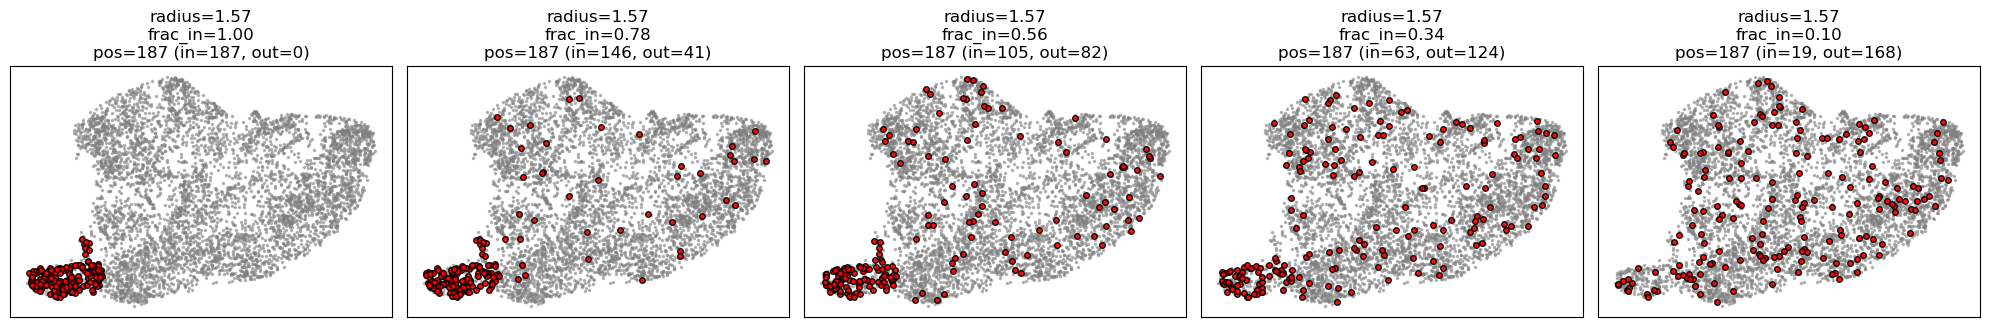

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

coords = ad_sim.obsm[coords_key]
n_tests = len(bleed_names)

plt.figure(figsize=(20, 4))
i_plots = np.floor(np.linspace(0, n_tests - 1, 5)).astype(int)

for j, i in enumerate(i_plots):
    ax = plt.subplot(1, 5, j + 1)

    # background cells
    ax.plot(coords[:, 0], coords[:, 1], '.', markersize=3, color='gray', alpha=0.5)

    # KDE contour of density (optional; can be slow on big n)
   #sns.kdeplot(
   #    x=coords[:, 0], y=coords[:, 1],
   #    levels=7, color='k', linewidths=1,
   #    ax=ax
   #)

    # get positive cells for this bleed gene
    xcol = ad_sim[:, bleed_names[i]].X
    if sp.issparse(xcol):
        pos = np.asarray(xcol.toarray()).ravel() > 0
    else:
        pos = np.asarray(xcol).ravel() > 0

    # overlay positives
    ax.plot(
        coords[pos, 0], coords[pos, 1],
        'o', markersize=4,
        markerfacecolor='r', markeredgecolor='k',
        alpha=0.9
    )

    n_pos = int(pos.sum())
    n_in = int((pos & (dists < radius0)).sum())
    n_out = n_pos - n_in

    ax.set_title(
        f"radius={radius0:.2f}\n"
        f"frac_in={fractions_in[i]:.2f}\n"
        f"pos={n_pos} (in={n_in}, out={n_out})"
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


In [14]:
data_dir = "/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations/"

In [15]:
data_dir = "/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations/"
ad_sim.write(data_dir+"support_files/sim_depletion.h5ad")

In [16]:
adata = sc.read_h5ad(data_dir+"support_files/sim_depletion.h5ad")
ad_sim = sc.read_h5ad(data_dir+"support_files/sim_depletion.h5ad")
if "X_umap" in adata.obsm:
    coords_key = "X_umap"
elif "coords" in adata.obsm:
    coords_key = "coords"
else:
    raise KeyError("No 2D coords found in adata.obsm['X_umap'] or adata.obsm['coords'].")

In [17]:
%%time
# Assuming you already have LOCAT imported in your environment
# from locat import LOCAT  (or wherever your LOCAT class lives)

coords_sim = ad_sim.obsm[coords_key].astype(np.float64)

knn = ad_sim.obsp["connectivities"] if "connectivities" in ad_sim.obsp else None

reset_seeds(SEED)
m = LOCAT(
    ad_sim,
    coords_sim,
    20,
    show_progress=True,
    n_bootstrap_inits=100,
    knn=knn
)

m.background_pdf(force_refresh=True)

sres = {
    "full": m.gmm_scan(
        max_freq=1.0,
        rc_lambda_values=np.linspace(1.0, 2.0, 8),
        include_depletion_scan=True,
    ),
    "local": m.gmm_local_scan(zscore_thresh=-np.inf, max_freq=1.0),
    "llr": m.gmm_loglikelihoodtest(max_freq=1.0),
    "lpval": m.gmm_local_pvalue(),
}

# Convenience: locate the bleeding gene names
bleed_genes = np.array([g for g in ad_sim.var_names if g.startswith("Sox2_bleed_")], dtype=object)


2026-03-17 11:37:07.758 | INFO     | locat.locat:background_pdf:427 - fitting background PDF
2026-03-17 11:37:07.760 | INFO     | locat.locat:background_n_components_init:197 - Estimating number of GMM components
estimating BIC for 5572 cells:   0%|                                           | 0/9 [00:00<?, ?it/s]2026-03-17 11:37:07.788 | INFO     | locat.locat:min_dist:135 - recomputing min cell-cell distance
2026-03-17 11:37:07.789 | INFO     | locat.locat:cell_dist:127 - recomputing cell-cell distance
estimating BIC for 74 cells: 100%|███████████████████████████████████| 30/30 [00:52<00:00,  1.76s/it]
2026-03-17 11:38:47.674 | INFO     | locat.locat:background_pdf:439 - Using 15 components
fitting background: 100%|████████████████████████████████████████████| 10/10 [00:02<00:00,  3.37it/s]
null distribution parameters (perm. pseudo-genes): 100%|███████████████| 7/7 [01:02<00:00,  8.93s/it]
scanning genes: 100%|████████████████████████████████████████████| 1050/1050 [31:46<00:00,  1.8

CPU times: user 2h 26min 43s, sys: 7h 54min 41s, total: 10h 21min 24s
Wall time: 42min 41s


In [18]:
#load sres
#res2 = load_res(path = "dermalc_depletion_sres.pkl")

In [19]:
# check total positives are constant across bleeds
import scipy.sparse as sp
Xb = ad_sim[:, bleed_genes].X
if sp.issparse(Xb):
    totals = np.asarray((Xb > 0).sum(axis=0)).ravel()
else:
    totals = (Xb > 0).sum(axis=0)

print("Bleed totals (min/max):", totals.min(), totals.max(), "target n_total:", n_total)

# check how many positives lie outside the core as bleeding increases
core_mask = dists < radius0
if sp.issparse(Xb):
    Xb_bool = (Xb > 0).astype(np.int8)
    outside = np.asarray(Xb_bool[~core_mask, :].sum(axis=0)).ravel()
else:
    outside = ((Xb > 0)[~core_mask, :]).sum(axis=0)

print("Outside-core positives first/last:", outside[0], outside[-1])


Bleed totals (min/max): 187 187 target n_total: 187
Outside-core positives first/last: 0 168


In [20]:
import cloudpickle as cp
def save_res(path):
    with open(f"{path}", "wb") as f:
        cp.dump(sres, f)

def load_res(path):
    with open(f"{path}", "rb") as f:
        loadedres = cp.load(f)
    return loadedres

In [21]:
#save sres
#save_res(path = "dermalc_depletion_sres.pkl")

In [22]:
#load_res(path = "dermalc_depletion_sres.pkl")

In [23]:
#pd.DataFrame(sres["full"]).T.sort_values(by="pval",ascending=False)["depletion_scan"][0]

In [24]:
#adata.obsm["coords"] = coords

In [25]:
if "X_pca" in adata.obsm:
    print(True)
    ad_sim.obsm["pca"] = adata.obsm["X_pca"].copy()

if "pca" in adata.uns:
    ad_sim.uns["pca"] = adata.uns["pca"].copy()

True


In [26]:
import simulations_compare_helpers as sim_helpers
from simulations_compare_helpers import (
    plotgenes,
    train_haystack_logpv_full,
    train_hotspot_full,
    train_clustering_logpadj,
    score_genes_with_graph_metrics,
    build_size_nulls,
    size_matched_pvalues,
)
srh = sim_helpers


In [27]:
%%time
# Assume: adata is log-normalized and adata.obsm['X_pca'] exists
scores = srh.score_genes_with_graph_metrics(
    ad_sim,
    n_neighbors=15,
    metric="euclidean",
    normalized_laplacian=True,  # L_sym (recommended)
    center=True,                # subtract per-gene means before scoring
    m_eigs=96,                  # try 64–256 (trade-off accuracy vs speed)
    use_connectivities=True,    # use scanpy’s kNN affinity graph
    layer=None                  # or your log layer name if you keep one
)
scores.head()


/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 48min 56s, sys: 0 ns, total: 48min 56s
Wall time: 1min 51s


,rayleigh_smoothness,spectral_entropy
Timm8a1,0.910154,0.662465
Otud7a,0.983368,0.787884
Pde4dip,0.987886,0.827395
Ccdc178,0.962223,0.692892
Rab11a,0.981242,0.695267


In [28]:
%%time
# 0) pick layer to use (log-normalized, ideally nonnegative)
layer = None  # or e.g. "log1p"

# 1) ensure neighbors built from PCs, then Laplacian/eigs + nulls
# (assumes adata_filt.obsp['connectivities'] exists)
reset_seeds(SEED)
bank = srh.build_size_nulls(ad_sim, W_key='connectivities', layer=layer,
                        normalized_laplacian=True, m_eigs=96, P=4096, seed=42)

# 2) observed scores you already computed:
scores = ad_sim.var[['rayleigh_smoothness','spectral_entropy']]

# 3) size-matched p-values / percentiles
scores_sz = srh.size_matched_pvalues(scores, bank, two_sided=False)
scores_sz.head()

CPU times: user 1h 15min 50s, sys: 0 ns, total: 1h 15min 50s
Wall time: 12min 54s


,rayleigh_smoothness,spectral_entropy,p_rayleigh_sizeNull,p_entropy_sizeNull,pct_rayleigh_sizeNull,pct_entropy_sizeNull
Timm8a1,0.910154,0.662465,1.000000,1.000000,1.000000,1.000000
Otud7a,0.983368,0.787884,0.069092,1.000000,0.069092,1.000000
Pde4dip,0.987886,0.827395,1.000000,1.000000,1.000000,1.000000
Ccdc178,0.962223,0.692892,0.000732,0.094971,0.000732,0.094971
Rab11a,0.981242,0.695267,1.000000,1.000000,1.000000,1.000000


In [29]:
scores_sz["HR_avg_sizeNull"] = scores_sz[["p_entropy_sizeNull", "pct_rayleigh_sizeNull"]].mean(axis=1)

In [30]:
%%time
SHres = dict()
res, trained_genes = train_haystack_logpv_full(
    ad_sim, 
    genesuse=ad_sim.var_names,
    emb="pca")
missing_genes = [i for i in list(ad_sim.var_names) if i not in list(trained_genes)]
missing_genes = np.random.default_rng(SEED).permutation(missing_genes)
trained_genes = np.concatenate([trained_genes, missing_genes])
ranks_res = [{i: list(trained_genes).index(i)} for i in list(ad_sim.var_names)]
SHres['ranks'] = ranks_res
SHres['out'] = res

> starting haystack ...
> entering array method ...
> scaling coordinates ...
> calculating feature stds ...
> calculating grid points ...
> calculating distance to cells ...
> calculating densities ...
> calculating Q dist ...
> calculating KLD for 1050 features ...


100%|██████████████████████████████████████████████████████████| 1050/1050 [00:00<00:00, 1089.22it/s]


> calculating feature's CV ...
> selecting genes to randomize ...
> calculating randomized KLD ...


100%|██████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.42it/s]


> calculating P values ...
> done.
CPU times: user 5min 34s, sys: 7min 51s, total: 13min 26s
Wall time: 59.3 s


In [31]:
pd.DataFrame(SHres["ranks"]).max(axis=0).sort_values()

Cdk1          0.0
Col7a1        1.0
Ube2c         2.0
Gadd45g       3.0
Kitl          4.0
            ...  
Cox15      1045.0
Oma1       1046.0
Aars2      1047.0
Ap4b1      1048.0
Fcer1g     1049.0
Length: 1050, dtype: float64

In [32]:
%%time
HSres = dict()
res, trained_genes = train_hotspot_full(
    ad_sim, 
    genesuse=ad_sim.var_names,
    emb="pca")
ranks_res = [{i: list(trained_genes).index(i)} for i in list(ad_sim.var_names)]
HSres['ranks'] = ranks_res
HSres["out"] = res

/home/wes/.conda/envs/mulde_jax/lib/python3.10/site-packages/hotspot/hotspot.py:98: UserWarning: Hotspot will work faster when counts are a csr sparse matrix.
  warnings.warn(
100%|████████████████████████████████████████████████████████████| 1050/1050 [00:19<00:00, 54.12it/s]


CPU times: user 2min 20s, sys: 6min 30s, total: 8min 50s
Wall time: 43.7 s


In [33]:
HSres["out"]

,C,Z,Pval,FDR
Gene,,,,
Ube2c,0.809741,261.329003,0.000000,0.000000
Klf4,0.672510,222.205869,0.000000,0.000000
Cdk1,0.676072,218.106708,0.000000,0.000000
Sox2,0.652081,209.697750,0.000000,0.000000
Hist1h1a,0.594550,191.346580,0.000000,0.000000
...,...,...,...,...
Mettl8,-0.003853,-1.252487,0.894804,0.898225
Slc22a21,-0.004332,-1.353744,0.912091,0.914704
Fcer1g,-0.004652,-1.488005,0.931625,0.933403


In [34]:
import numpy as np
import scipy.sparse as sp
from giniclust3.gini import giniIndex, loessRegression, giniValueSelectionM

def custom_calGini(adata, selection="p_value", min_gini_value=0.6, p_value=0.0001):
    gene_labels = adata.var_names.tolist()
    cell_labels = adata.obs_names.tolist()

    print(f"Gene number is {len(gene_labels)}")
    print(f"Cell number is {len(cell_labels)}")

    X = adata.X
    if sp.issparse(X):
        X = X.toarray()  # cells x genes, dense

    # giniclust expects genes x cells
    gene_gini, gene_max = giniIndex(X.T)

    log_gene_max = np.log2(np.array(gene_max) + 0.1)
    adata.var["gini_score"] = np.array(gene_gini)

    if selection == "p_value":
        sig_gini_genes, _ = loessRegression(gene_gini, log_gene_max, gene_labels, min_gini_value, p_value)
        passed = set(sig_gini_genes.keys())
    elif selection == "gini_value":
        sig_gini_genes = giniValueSelectionM(gene_gini, gene_labels, min_gini_value)
        passed = set(sig_gini_genes.keys())
    else:
        raise ValueError("selection must be 'p_value' or 'gini_value'")

    adata.var["gini_pass"] = adata.var_names.isin(list(passed))
    print(f"Identified {int(adata.var['gini_pass'].sum())} high-Gini genes")
    return adata


In [35]:
%%time
ad_sim = custom_calGini(ad_sim, min_gini_value=0.6, p_value=0.0001, selection="gini_value")

Gene number is 1050
Cell number is 5572
Identified 881 high-Gini genes
CPU times: user 301 ms, sys: 6.37 ms, total: 307 ms
Wall time: 443 ms


In [36]:
data_dir = "/banach2/wes/Locat-paper-repro-private/notebooks/figures/Simulations/"

In [37]:
gspa_data = np.load(data_dir + "support_files/gspa_output_depl_comp_repro.npz", allow_pickle=True)
gspa_var_names = gspa_data["var_names"]
gspa_gene_localization = gspa_data["gene_localization"]

In [38]:
ad_sim.var["gspa"] = gspa_gene_localization

In [39]:
lmd_res = np.load(data_dir+"support_files/LMD_output_depl_comp_repro.npz",  allow_pickle=True)

In [40]:
var_names = lmd_res["var_names"]
gene_localization = lmd_res["gene_localization"]

In [41]:
lmd_res = pd.DataFrame({
    "var_names": var_names,
    "LMD_score": gene_localization}).set_index("var_names")

In [42]:
ad_sim.obsp["connectivities"] = adata.obsp["connectivities"]
ad_sim.uns["neighbors"] = adata.uns["neighbors"]

In [43]:
%%time
STres = dict()
clust = train_clustering_logpadj(ad_sim, genesuse=ad_sim.var_names)
ranked_genes = clust.index.to_list()
rank_map = {g: i for i, g in enumerate(ranked_genes)}

# If some genes didn't appear (shouldn’t, but safe), give them worst rank
worst = len(ranked_genes)
STres["truth"] = [{g: rank_map.get(g, worst)} for g in ad_sim.var_names]

CPU times: user 33.8 s, sys: 0 ns, total: 33.8 s
Wall time: 6.65 s


In [44]:
#clust
clust["pvals_adj"]

gene
Smc4       0.000000e+00
Cdk1       0.000000e+00
Meg3       0.000000e+00
Ube2c      0.000000e+00
Ska1      7.174536e-266
              ...      
Fcer1g     9.471133e-01
Usp35      9.505667e-01
Egf        9.591657e-01
Tor3a      9.594282e-01
Acot11     9.724537e-01
Name: pvals_adj, Length: 1050, dtype: float64

In [45]:
#spectralRH
scores_sz["HR_avg_sizeNull"]#.value_counts()

Timm8a1           1.000000
Otud7a            0.534546
Pde4dip           1.000000
Ccdc178           0.047852
Rab11a            1.000000
                    ...   
Sox2_bleed_045    0.976929
Sox2_bleed_046    0.999512
Sox2_bleed_047    0.999756
Sox2_bleed_048    0.986938
Sox2_bleed_049    1.000000
Name: HR_avg_sizeNull, Length: 1050, dtype: float64

In [46]:
#HAYSTACK
SHres['out']

,gene,KLD,CV,pval,pval_adj,logpval,logpval_adj
0,Timm8a1,0.000047,1.121351,2.038646e-14,2.140578e-11,-13.690658,-10.669469
1,Otud7a,0.000301,7.699724,9.221475e-03,1.000000e+00,-2.035200,0.000000
2,Pde4dip,0.000035,2.430498,7.703466e-02,1.000000e+00,-1.113314,0.000000
3,Ccdc178,0.001060,9.449036,1.327714e-06,1.394100e-03,-5.876896,-2.855706
4,Rab11a,0.000015,1.000435,5.448507e-05,5.720933e-02,-4.263722,-1.242533
...,...,...,...,...,...,...,...
1045,Sox2_bleed_045,0.000129,5.366264,5.912203e-02,1.000000e+00,-1.228251,0.000000
1046,Sox2_bleed_046,0.000136,5.366264,4.814189e-02,1.000000e+00,-1.317477,0.000000
1047,Sox2_bleed_047,0.000112,5.366264,9.654311e-02,1.000000e+00,-1.015279,0.000000
1048,Sox2_bleed_048,0.000068,5.366264,3.475418e-01,1.000000e+00,-0.458993,0.000000


In [47]:
#HOTSPOT
HSres["out"]

,C,Z,Pval,FDR
Gene,,,,
Ube2c,0.809741,261.329003,0.000000,0.000000
Klf4,0.672510,222.205869,0.000000,0.000000
Cdk1,0.676072,218.106708,0.000000,0.000000
Sox2,0.652081,209.697750,0.000000,0.000000
Hist1h1a,0.594550,191.346580,0.000000,0.000000
...,...,...,...,...
Mettl8,-0.003853,-1.252487,0.894804,0.898225
Slc22a21,-0.004332,-1.353744,0.912091,0.914704
Fcer1g,-0.004652,-1.488005,0.931625,0.933403


In [48]:
#GINI
ad_sim.var["gini_score"].value_counts()

gini_score
0.966437    50
0.987484     1
0.966309     1
0.831649     1
0.990306     1
            ..
0.975838     1
0.990457     1
0.821004     1
0.823757     1
0.877844     1
Name: count, Length: 1001, dtype: int64

In [49]:
#LMD
lmd_res

,LMD_score
var_names,
Timm8a1,9.292311
Otud7a,8.624225
Pde4dip,9.418986
Ccdc178,8.268684
Rab11a,9.623533
...,...
Sox2_bleed_045,8.991600
Sox2_bleed_046,9.012700
Sox2_bleed_047,8.990271


In [50]:
#GSPA
ad_sim.var["gspa"].sort_values()

Rplp2        0.356870
Rplp1        0.368597
Rps29        0.421174
Rpl32        0.437434
Rpl38        0.469736
              ...    
Kif4         8.555431
Cdk1         9.260466
Hist1h1a     9.473931
Klf4        10.077618
Ube2c       10.772054
Name: gspa, Length: 1050, dtype: float64

In [51]:
#sc.pl.embedding(ad_sim,basis="coords",color=["Gene_64","Gene_94","Gene_31","Gene_190","Gene_193","Gene_199"], s=50, cmap="Reds")

In [52]:
example_gene = next(iter(sres["full"]))
sres["full"][example_gene]


LocatResult(gene_name='Timm8a1', bic=-0.14472381414448035, zscore=9.444094956041749, sens_score=0.41714697406340057, depletion_pval=0.06673687623172946, concentration_pval=1e-15, h_size=0.00036003599971046185, h_sens=0.5828530249365994, pval=0.06995910570395014, K_components=3, sample_size=2776.0, depletion_scan={'p_value': 0.06673687623172946, 'raw_min_p': 0.06673687623172946, 'log_p_single': -2.706997611792815, 'log_p_sidak': -2.706997611792815, 'neglog10_p_single': 1.1756341253269005, 'neglog10_p_sidak': 1.1756341253269005, 'best_lambda': 1.1428571428571428, 'k_obs_eff': 39, 'p0_abs': 0.6667931664285524, 'obs_prop': 0.531700288184438, 'scanned': 2, 'tested': 2, 'sidak_penalty': 2, 'n': 5572, 'n_eff_g': 74.0, 'n_trials_eff': 74, 'guards': {'min_p0_abs': 0.1, 'min_expected': 3.0, 'min_abs_deficit': 0.04, 'soft_bound': 1.0, 'eps_rel': 0.01}, 'n_eff_scale': 0.6, 'rho_bb': 0.02, 'per_lambda': [{'lambda': 1.0, 'p0_abs': 0.7292815230958025, 'obs_prop': 0.6019452449567723, 'n_eff_g': 74.0, 

In [53]:
locat_df = pd.DataFrame({gene: res._asdict() for gene, res in sres["full"].items()}).T
locat_df.index.name = "gene"
locat_df


,gene_name,bic,zscore,sens_score,depletion_pval,concentration_pval,h_size,h_sens,pval,K_components,sample_size,depletion_scan
gene,,,,,,,,,,,,
Timm8a1,Timm8a1,-0.144724,9.444095,0.417147,0.066737,0.0,0.00036,0.582853,0.069959,3,2776.0,"{'p_value': 0.06673687623172946, 'raw_min_p': ..."
Otud7a,Otud7a,0.220582,4.744239,0.633663,0.000321,0.000001,0.009756,0.366337,0.044429,2,101.0,"{'p_value': 0.0003213795118273683, 'raw_min_p'..."
Pde4dip,Pde4dip,-0.062883,-1.137023,0.359462,0.22186,0.872236,0.001118,0.640538,0.693066,3,893.0,"{'p_value': 0.2218595615463987, 'raw_min_p': 0..."
Ccdc178,Ccdc178,0.200396,10.013301,0.855072,0.0,0.0,0.014184,0.144928,0.018088,2,69.0,"{'p_value': 2.3857248751145974e-07, 'raw_min_p..."
Rab11a,Rab11a,-0.143134,5.595604,0.36,0.197175,0.0,0.00032,0.64,0.076815,3,3125.0,"{'p_value': 0.19717511224343898, 'raw_min_p': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
Sox2_bleed_045,Sox2_bleed_045,0.173805,2.66224,0.486631,0.028214,0.003881,0.005305,0.513369,0.068256,3,187.0,"{'p_value': 0.0282140063446434, 'raw_min_p': 0..."
Sox2_bleed_046,Sox2_bleed_046,0.200903,1.5669,0.379679,0.062086,0.058569,0.005305,0.620321,0.130459,3,187.0,"{'p_value': 0.062085895702188545, 'raw_min_p':..."
Sox2_bleed_047,Sox2_bleed_047,0.22058,1.487941,0.42246,0.022964,0.068383,0.005305,0.57754,0.101584,3,187.0,"{'p_value': 0.022964049144341452, 'raw_min_p':..."


In [54]:
#Locat
locat_p = locat_df["pval"].astype(float)
locat_conc_p = locat_df["concentration_pval"].astype(float)
locat_llr_p = pd.DataFrame(sres["llr"]).T["llratio_pvalue"].astype(float)
locat_perm_p = pd.DataFrame(sres["lpval"]).T["zscore_pvalue"].astype(float)


In [55]:
bleed_indices = [f"Sox2_bleed_{i:03d}" for i in range(len(fractions_in))]
truth_out = pd.Series(1.0 - fractions_in, index=bleed_indices, name="frac_out")
x = truth_out.reindex(bleed_indices).to_numpy()


In [56]:
# clustering: DataFrame indexed by gene with pvals_adj
clust_p = clust["pvals_adj"].astype(float)

# hotspot: DataFrame indexed by gene with FDR
hotspot_p = HSres["out"]["FDR"].astype(float)

# haystack: DataFrame with gene + pval_adj
haystack_p = SHres["out"].set_index("gene")["pval_adj"].astype(float)

# spectralRH size-null score is already "p-like" (smaller better)
srh_p = scores_sz["HR_avg_sizeNull"].astype(float)

# GSPA: score -> rank-based p (monotone, not calibrated)
gspa = ad_sim.var["gspa"].astype(float)
gspa_rankp = (gspa.rank(ascending=False, method="average") / (len(gspa) + 1)).astype(float)

lmd = lmd_res["LMD_score"].astype(float)
lmd_rankp = (lmd.rank(ascending=True, method="average") / (len(lmd) + 1)).astype(float)



In [64]:
from pathlib import Path
FIG_DIR = Path("DermalC_sim_repro_svgs")
FIG_DIR.mkdir(exist_ok=True)
def save_svg(fig, stem):
    import matplotlib.pyplot as plt

    if fig is None:
        fig = plt.gcf()
    path = FIG_DIR / f"{stem}.svg"
    fig.savefig(path, format="svg", bbox_inches="tight")
    print(f"Saved {path}")
    return fig
        

Saved DermalC_sim_repro_svgs/sox2_bleeding_sensitivity_methods.svg


''

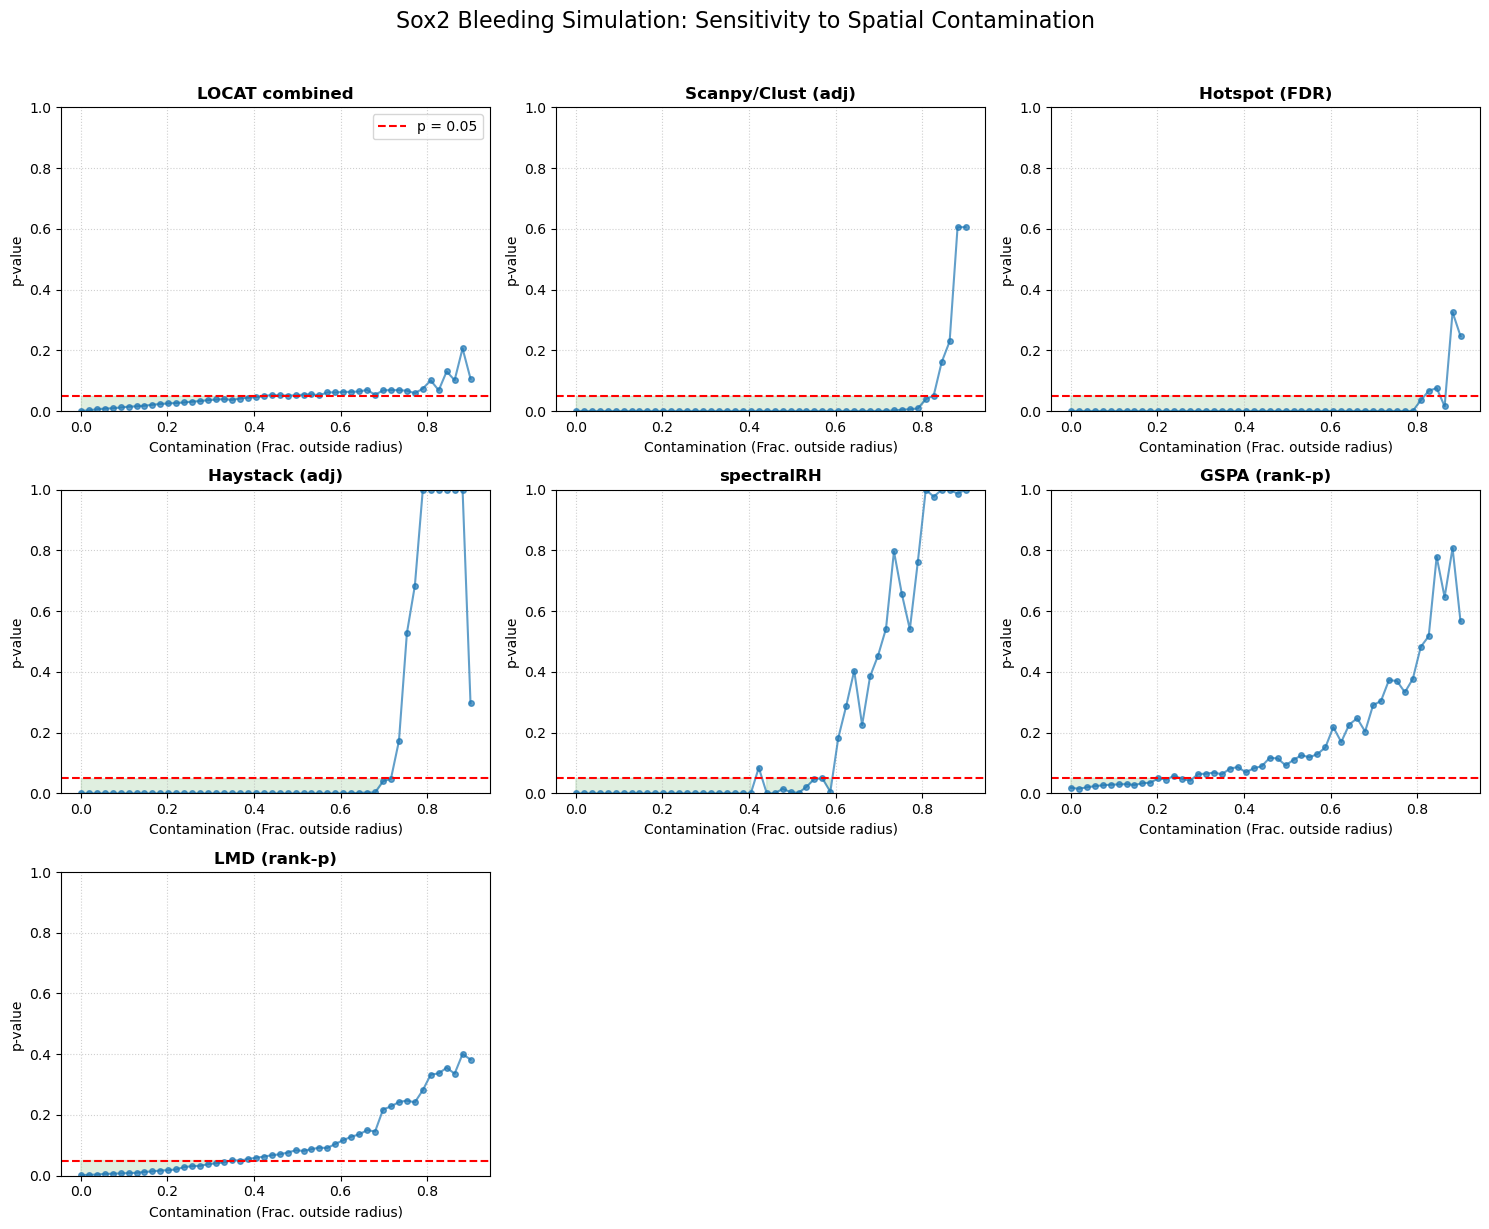

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_vals = 1.0 - fractions_in
bleed_indices = [f"Sox2_bleed_{i:03d}" for i in range(50)]

sig_p = 0.05
methods = {
    "LOCAT combined": locat_p,
    "Scanpy/Clust (adj)": clust_p,
    "Hotspot (FDR)": hotspot_p,
    "Haystack (adj)": haystack_p,
    "spectralRH": srh_p,
    "GSPA (rank-p)": gspa_rankp,
    "LMD (rank-p)": lmd_rankp,
}

n = len(methods)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig = plt.figure(figsize=(5 * ncols, 4 * nrows))

for i, (name, pv) in enumerate(methods.items(), 1):
    pv_series = (
        pd.Series(pv)
        .reindex(bleed_indices)
        .astype(float)
        .to_numpy()
    )

    ax = plt.subplot(nrows, ncols, i)
    ax.plot(x_vals, pv_series, 'o-', markersize=4, alpha=0.7, color='tab:blue')
    ax.axhline(sig_p, color="red", linestyle="--", linewidth=1.5, label="p = 0.05")
    ax.fill_between(
        x_vals,
        pv_series,
        sig_p,
        where=(pv_series <= sig_p),
        color='green',
        alpha=0.12
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Contamination (Frac. outside radius)")
    ax.set_ylabel("p-value")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.6)

    if i == 1:
        ax.legend(loc='upper right')

fig.suptitle(
    "Sox2 Bleeding Simulation: Sensitivity to Spatial Contamination",
    fontsize=16,
    y=1.02,
)
fig.tight_layout()

save_svg(fig, "sox2_bleeding_sensitivity_methods")
#display(fig)
;
